Dataset Info:
Shape: (6607, 20)
Columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

First 5 rows:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No      

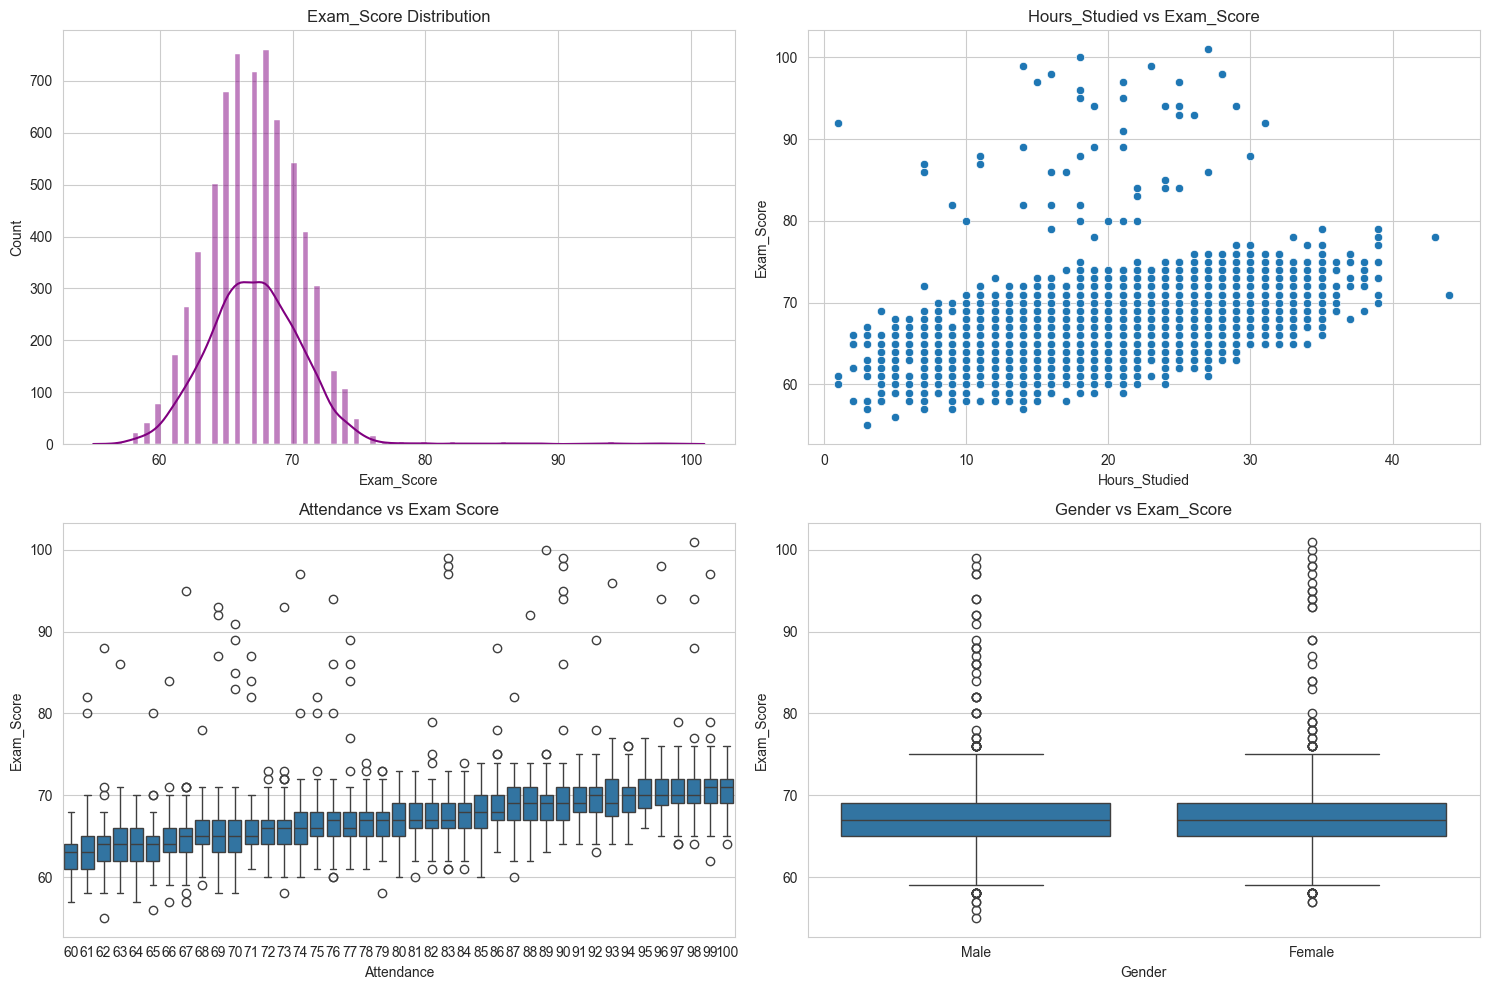

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load and explore data
def load_and_explore_students(filename):
    df = pd.read_csv(filename)
    df.columns = df.columns.str.strip()

    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nMissing values:")
    print(df.isnull().sum())

    return df

# Student performance analysis
def analyze_students(df):
    score_col = 'Exam_Score'

    avg_score = df[score_col].mean()
    score_distribution = df[score_col].describe()

    numeric_cols = df.select_dtypes(include=['number']).columns
    correlations = df[numeric_cols].corr()[score_col].sort_values(ascending=False)

    attendance_score = df.groupby('Attendance')[score_col].mean() if 'Attendance' in df.columns else None
    gender_score = df.groupby('Gender')[score_col].mean() if 'Gender' in df.columns else None
    parental_score = df.groupby('ParentalInvolvement')[score_col].mean() if 'ParentalInvolvement' in df.columns else None

    return avg_score, score_distribution, correlations, attendance_score, gender_score, parental_score

# Visualization
def plot_student_insights(df):
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.histplot(df['Exam_Score'], kde=True, color='purple')
    plt.title('Exam_Score Distribution')

    plt.subplot(2, 2, 2)
    sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score')
    plt.title('Hours_Studied vs Exam_Score')

    plt.subplot(2, 2, 3)
    sns.boxplot(data=df, x='Attendance', y='Exam_Score')
    plt.title('Attendance vs Exam Score')

    plt.subplot(2, 2, 4)
    sns.boxplot(data=df, x='Gender', y='Exam_Score')
    plt.title('Gender vs Exam_Score')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    df = load_and_explore_students(r"C:\Users\Dell\Desktop\Task2\StudentPerformanceFactors.csv")
    avg_score, score_distribution, correlations, attendance_score, gender_score, parental_score = analyze_students(df)

    print("\nAverage Score:")
    print(avg_score)

    print("\nScore Distribution:")
    print(score_distribution)

    print("\nCorrelations with Exam Score:")
    print(correlations)

    print("\nAttendance vs Score:")
    print(attendance_score)

    print("\nGender vs Score:")
    print(gender_score)

    print("\nParental Involvement vs Score:")
    print(parental_score)

    plot_student_insights(df)


# Student Performance Analysis Report

## Objective
The objective of this project is to understand which factors influence student exam performance.

## Dataset Features
- HoursStudied
- Attendance
- ParentalInvolvement
- PreviousScores
- MotivationLevel
- SchoolType
- Gender
- ExamScore

## Analysis Performed
- Average score analysis
- Score distribution analysis
- Correlation between numeric variables and exam score
- Attendance-wise score comparison
- Gender-wise score comparison
- Parental involvement analysis

## Key Insights
- Study hours can be linked with exam outcomes.
- Attendance level may influence student performance.
- Previous scores often help explain current scores.
- Parental involvement may show a measurable impact.
- Distribution analysis helps identify spread and consistency in marks.

## Conclusion
This project demonstrates exploratory analysis and factor-based performance evaluation using Python.
